# Experiment Analysis

This notebook analyzes the experiment results from `20251130` and `20251201`.

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import importlib
import log_parser
from IPython.display import set_matplotlib_formats

# Force reload to pick up latest changes
importlib.reload(log_parser)

# Set SVG rendering
set_matplotlib_formats('svg')

# Set plot style and context
sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5})
sns.set_context("notebook", font_scale=1)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

/tmp/ipykernel_221250/2709768028.py:15: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg')


In [2]:
# Define directories
# We check where we are running from to construct paths correctly
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

dirs = ['20251130/base', '20251201/base', '20251202/base', '20251203', '20251204']
# dirs = ['20251203']

if 'workspace/exp/harness' in cwd:
    # Running inside harness dir
    target_dirs = [d for d in dirs]
else:
    # Assuming running from project root
    target_dirs = [os.path.join('workspace/exp/harness', d) for d in dirs]

# Get successful logs
logs = log_parser.get_successful_logs(target_dirs)
print(f"Found {len(logs)} successful logs")

Current working directory: /iopsstor/scratch/cscs/xjin/repos/sglang/workspace/exp/harness
Found 266 successful logs


In [3]:
# Parse logs and extract info
data = []
for log in logs:
    try:
        info = log_parser.get_experiment_info(log)
        score = info.extract_score()
        if score is not None:
            entry = info.params.copy()
            entry['score'] = score
            # Ensure specific columns are present and consistent
            entry['task'] = info.task
            entry['model'] = info.model
            entry['method'] = info.method
            
            # Convert numeric fields
            for k in ['bsz', 'pg', 'graph', 'run', 'topk', 'wind', 'sink']:
                if k in entry:
                    try:
                        if entry[k] != 'auto' and entry[k] != 'none':
                            entry[k] = int(entry[k])
                    except ValueError:
                        pass
            for k in ['frac', 'limit']:
                 if k in entry:
                    try:
                        if entry[k] != 'none':
                            entry[k] = float(entry[k])
                    except ValueError:
                        pass
            data.append(entry)
    except Exception as e:
        print(f"Error processing {log}: {e}")

df = pd.DataFrame(data)
print(f"Parsed {len(df)} records")
if not df.empty:
    display(df.head())
else:
    print("DataFrame is empty. Check logs path or log content.")

Parsed 266 records


,method,model,pg,graph,frac,limit,bsz,ctx,tasks,topk,est,run,score,task,wind,sink
0,quest,qw_30b_th,16,1,0.74,none,8,none,aime24,16.0,triton,1,0.033300,aime24,NaN,NaN
1,stream,qw_30b_th,16,1,0.74,none,8,none,ruler,NaN,NaN,1,0.552700,ruler,2048.0,4.0
2,quest,qw_30b_th,16,1,0.74,none,8,none,aime24,32.0,triton,1,0.000000,aime24,NaN,NaN
3,stream,qw_4b,1,1,0.74,none,8,none,mmlu,NaN,NaN,1,0.705200,mmlu,256.0,4.0
4,stream,qw_30b_th,16,1,0.76,none,8,none,longbench,NaN,NaN,1,0.135317,longbench,128.0,4.0


In [4]:
# Pivot table to see results by Task and Method/Model
if not df.empty and 'score' in df.columns:
    pivot = df.pivot_table(index=['task', 'model'], columns=['method'], values='score', aggfunc='mean')
    display(pivot)
else:
    print("Cannot create pivot table: DataFrame is empty or missing 'score' column.")

method                   base     quest    stream
task      model                                  
aime24    qw_30b     0.066700  0.023800  0.020000
          qw_30b_th  0.133300  0.014271  0.006660
          qw_4b      0.400000  0.166662  0.053340
          qw_4b_th   0.133300  0.083325  0.020000
longbench qw_30b     0.345500  0.142485  0.216448
          qw_30b_th  0.249517  0.104642  0.152927
          qw_4b      0.309700  0.130985  0.171488
          qw_4b_th   0.260033  0.101065  0.151840
mmlu      qw_30b     0.800300  0.801700  0.801680
          qw_30b_th  0.786600  0.785412  0.785420
          qw_4b      0.705600  0.705550  0.705550
          qw_4b_th   0.685700  0.685800  0.685780
ruler     qw_30b     0.956400  0.213475  0.355190
          qw_30b_th  0.852300  0.174037  0.270560
          qw_4b      0.939200  0.320825  0.347690
          qw_4b_th   0.860500  0.260175  0.287440

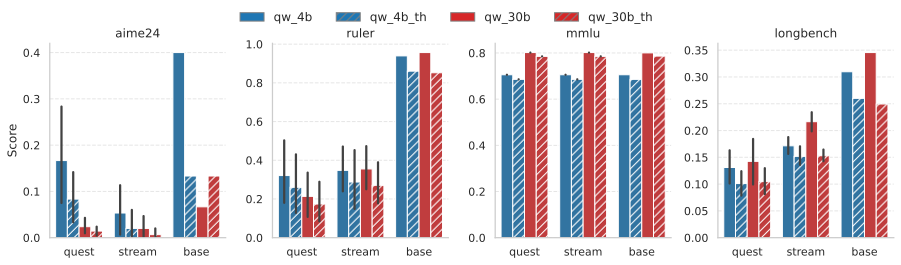

In [5]:
# Simple Visualization: Score by Method for each Task
if not df.empty and 'score' in df.columns:
    # Define model colors
    model_colors = {
        'qw_4b': '#1f77b4',      # blue
        'qw_4b_th': '#1f77b4',   # blue
        'qw_30b': '#d62728',     # red
        'qw_30b_th': '#d62728'   # red
    }
    hue_order = ['qw_4b', 'qw_4b_th', 'qw_30b', 'qw_30b_th']
    
    g = sns.catplot(
        data=df,
        x="method", 
        y="score", 
        col="task", 
        hue="model",
        hue_order=hue_order,
        palette=model_colors,
        kind="bar",
        height=4, 
        aspect=0.8,
        sharey=False,
        legend=False # Custom legend
    )
    g.set_axis_labels("", "Score") # Remove X label
    g.set_titles("{col_name}")
    
    # Add hatches for _th models
    for ax in g.axes.flat:
        bars = ax.patches
        n_patches = len(bars)
        n_hues = len(hue_order)
        if n_patches % n_hues == 0:
            n_per_hue = n_patches // n_hues
            # th models are at index 1 and 3 in hue_order
            
            # Apply hatch to qw_4b_th
            for i in range(n_per_hue, 2 * n_per_hue):
                bars[i].set_hatch('///')
            
            # Apply hatch to qw_30b_th
            for i in range(3 * n_per_hue, 4 * n_per_hue):
                bars[i].set_hatch('///')
    
    # Create custom legend
    legend_handles = []
    for model in hue_order:
        color = model_colors[model]
        hatch = '///' if '_th' in model else None
        # Ensure edge color matches or is compatible. Gray edge is standard for bars.
        # facecolor must be set to ensure it's not white if hatch is present.
        patch = mpatches.Patch(facecolor=color, hatch=hatch, label=model, edgecolor='gray')
        legend_handles.append(patch)
    
    # Adjust figure layout to make room for legend
    g.fig.subplots_adjust(top=0.85)
    g.fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 0.88), ncol=4, frameon=False, fontsize=12)
    plt.show()
else:
    print("Cannot plot: DataFrame is empty or missing 'score' column.")

### Quest Analysis: Top-K vs Score

Analysis of how the Top-K parameter affects the score in the `quest` method, comparing different Page Sizes (`pg`) and Models.

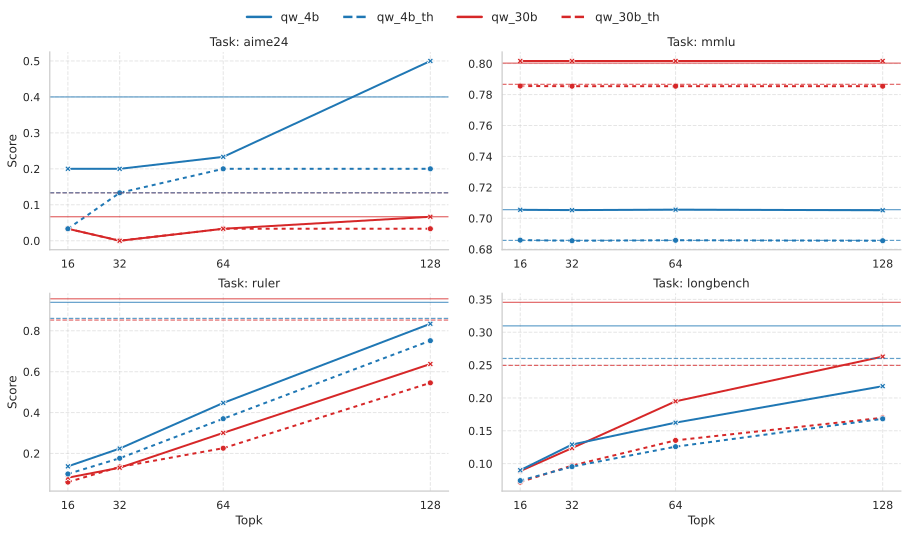

In [6]:
def plot_with_baseline(data_df, x_axis, style_col, title_prefix):
    if not data_df.empty:
        plot_data = data_df.copy()

        # Quest plots only use pg=16 results
        if title_prefix == "Quest" and 'pg' in plot_data.columns:
            plot_data = plot_data[plot_data['pg'] == 16]
            if plot_data.empty:
                print("No Quest results found for pg=16.")
                return

        # Color: 4b -> blue, 30b -> red
        def get_color_key(row):
            if "4b" in row['model']:
                return "blue"
            return "red"

        plot_data['color_key'] = plot_data.apply(get_color_key, axis=1)

        # Line style: thinking models -> dashed
        def get_style_key(row):
            return "dashed" if "_th" in row['model'] else "solid"

        plot_data['style_key'] = plot_data.apply(get_style_key, axis=1)

        color_map = {
            "blue": "#1f77b4",
            "red": "#d62728"
        }
        dash_map = {
            "solid": "",
            "dashed": (2, 2)
        }

        g = sns.relplot(
            data=plot_data,
            x=x_axis,
            y="score",
            hue="color_key",
            style="style_key",
            palette=color_map,
            dashes=dash_map,
            col="task",
            col_wrap=2,
            kind="line",
            markers=True,
            height=4,
            aspect=1.6,
            facet_kws={'sharey': False, 'sharex': False},
            linewidth=2,
            legend=False
        )

        axes = g.axes.flatten()

        baseline_df = df[df['method'] == 'base'].copy()
        if not baseline_df.empty:
            baseline_scores = baseline_df.groupby(['task', 'model'])['score'].mean().to_dict()

            for ax, task in zip(axes, g.col_names):
                task_data = plot_data[plot_data['task'] == task]
                if not task_data.empty:
                    unique_x = sorted(task_data[x_axis].unique())
                    ax.set_xticks(unique_x)
                    ax.set_xticklabels([int(x) for x in unique_x])
                # ax.xaxis.set_major_locator(MaxNLocator(integer=True))

                for model in data_df[data_df['task'] == task]['model'].unique():
                    base_score = baseline_scores.get((task, model))
                    if base_score is not None:
                        color = "#1f77b4" if "4b" in model else "#d62728"
                        linestyle = "--" if "_th" in model else "-"
                        ax.axhline(y=base_score, linestyle=linestyle, color=color, alpha=0.7, linewidth=1.2)

        g.set_axis_labels(x_axis.capitalize(), "Score")
        g.set_titles("Task: {col_name}")

        from matplotlib.lines import Line2D
        legend_handles = []
        legend_models = ['qw_4b', 'qw_4b_th', 'qw_30b', 'qw_30b_th']
        for model in legend_models:
            if model in plot_data['model'].unique():
                color = "#1f77b4" if "4b" in model else "#d62728"
                linestyle = "--" if "_th" in model else "-"
                legend_handles.append(Line2D([0], [0], color=color, linestyle=linestyle, lw=2.5, label=model))

        g.fig.subplots_adjust(top=0.85)
        g.fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 0.88), ncol=4, frameon=False, fontsize=12)

        plt.show()
    else:
        print(f"No data found for {title_prefix}")

if not df.empty and 'score' in df.columns:
    quest_df = df[df['method'] == 'quest'].copy()
    plot_with_baseline(quest_df, "topk", "pg", "Quest")
else:
    print("Cannot plot: DataFrame is empty or missing 'score' column.")

In [7]:
# show all data
print(df[(df['method']=='quest')&(df['task']=='longbench')&(df['pg']==8)&(df['model']!='qw_4b')].sort_values(by='model', ascending=False))
# print(df)

    method      model  pg  graph  frac limit  bsz   ctx      tasks   topk     est  run     score       task  wind  sink
54   quest   qw_4b_th   8      1  0.72  none    8  none  longbench   64.0  triton    1  0.095067  longbench   NaN   NaN
103  quest   qw_4b_th   8      1  0.72  none    8  none  longbench   32.0  triton    1  0.072817  longbench   NaN   NaN
121  quest   qw_4b_th   8      1  0.72  none    8  none  longbench  128.0  triton    1  0.120150  longbench   NaN   NaN
203  quest   qw_4b_th   8      1  0.72  none    8  none  longbench   16.0  triton    1  0.056850  longbench   NaN   NaN
20   quest  qw_30b_th   8      1  0.76  none    8  none  longbench   16.0  triton    1  0.054283  longbench   NaN   NaN
29   quest  qw_30b_th   8      1  0.76  none    8  none  longbench   32.0  triton    1  0.076450  longbench   NaN   NaN
179  quest  qw_30b_th   8      1  0.76  none    8  none  longbench  128.0  triton    1  0.130483  longbench   NaN   NaN
211  quest  qw_30b_th   8      1  0.76  

### Stream Analysis: Window Size vs Score

Analysis of how the Window Size (`wind`) parameter affects the score in the `stream` method.

Filtering Stream results for pg=1 as requested.


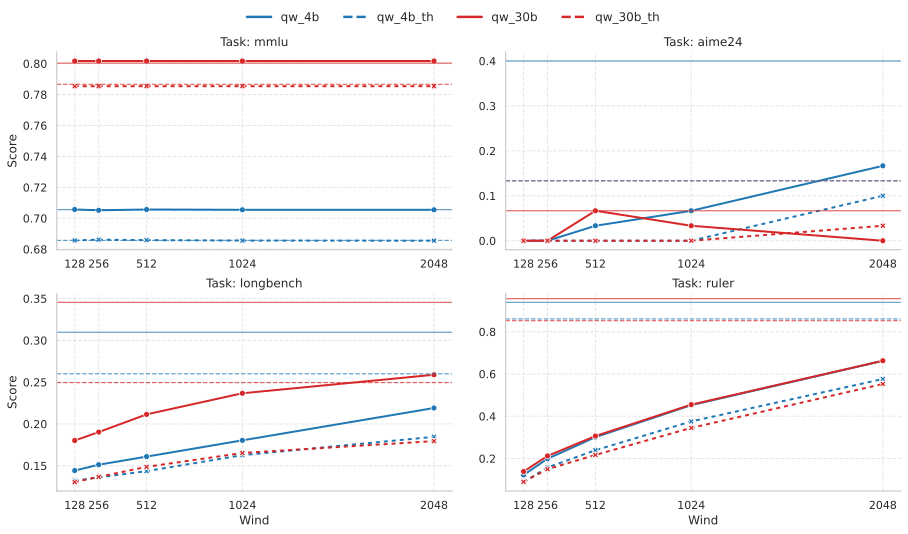

In [8]:
if not df.empty and 'score' in df.columns:
    # Filter for 'stream' method
    stream_df = df[df['method'] == 'stream'].copy()
    
    # Filter for pg=1 if available, as requested
    # First check if 1 exists in the 'pg' column for stream
    if 'pg' in stream_df.columns:
        # Check values
        available_pgs = stream_df['pg'].unique()
        if 1 in available_pgs:
            print("Filtering Stream results for pg=1 as requested.")
            stream_df = stream_df[stream_df['pg'] == 1]
        else:
            print(f"Note: pg=1 not found in Stream results (available: {available_pgs}). Using all available data.")
    
    plot_with_baseline(stream_df, "wind", "sink", "Stream")
else:
    print("Cannot plot: DataFrame is empty or missing 'score' column.")